# Customer Churn Prediction using Machine Learning

## Project Overview

Customer churn is one of the major challenges faced by telecommunication companies. Acquiring new customers is generally more expensive than retaining existing ones, making customer retention a key business objective.

The goal of this project is to predict whether a customer is likely to churn using machine learning techniques and derive actionable insights that can help improve customer retention.

The project uses the IBM Telco Customer Churn dataset and follows a complete end-to-end machine learning workflow, including:

- Data cleaning
- Exploratory Data Analysis
- Feature Engineering
- Logistic Regression
- Decision Trees
- Random Forest
- Cross Validation
- Hyperparameter Tuning
- Model Interpretation
- Business Recommendations


## 1. Problem Statement

Customer churn refers to customers leaving a company's services. Understanding and predicting churn allows businesses to proactively identify at-risk customers and implement retention strategies.

### Objective

Build machine learning models capable of predicting customer churn and identify the factors that influence customer attrition.

## 2. Import Libraries

In [1]:
#Data Manipulation
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.model_selection import train_test_split

#Settings
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

##3. Load Dataset

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

##4. Data Understanding

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print('Rows and Columns : ',df.shape)

Rows and Columns :  (7043, 21)


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Initial Observations

- The dataset contains customer demographic and service-related information.
- Both numerical and categorical variables are present.
- The target variable is `Churn`, indicating whether a customer has left the company.
- Further cleaning and preprocessing are required before model development.

##5. Data Cleaning

### Missing Values

In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#### Observation

No missing values were present in the dataset. Therefore, no imputation techniques were required during the data cleaning stage.

### Duplicate Values

In [9]:
df.duplicated().sum()

np.int64(0)

#### Observation

No duplicate records were detected in the dataset, ensuring that each customer observation is unique.

### Handling TotalCharges

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')

#### Observation

The `TotalCharges` feature was converted from object type to numerical format, enabling statistical analysis and model development.

In [11]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [12]:
df.dropna(inplace = True)

#### Observation

The dataset contains very few missing values. Missing entries in `TotalCharges` were caused by customers with zero tenure and were handled appropriately.

### Removing Irrelevant Features

In [13]:
df.drop('customerID',axis=1,inplace=True)

#### Observation

`customerID` is merely an identifier and does not contain predictive information, so it was removed.

## 6. Exploratory Data Analysis

In [14]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [15]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.421502
Yes,26.578498


### Churn Distribution

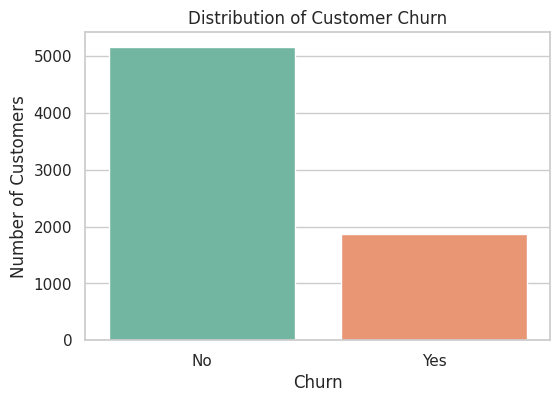

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn',
              data=df,
              palette='Set2')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Churn')
plt.show()

#### Observation

Most customers remain with the company, although a substantial proportion have churned. This indicates a moderate class imbalance.

### Numerical Columns and Categorical Columns

In [17]:
numerical_cols = df.select_dtypes(include = np.number).columns
categorical_cols = df.select_dtypes(exclude = np.number).columns

print(f'Numerical Features \n{numerical_cols}')
print(f'\nCategorical Features \n{categorical_cols}')

Numerical Features 
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Features 
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [18]:
df[numerical_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Distribution of Numerical Variables

<Figure size 700x700 with 0 Axes>

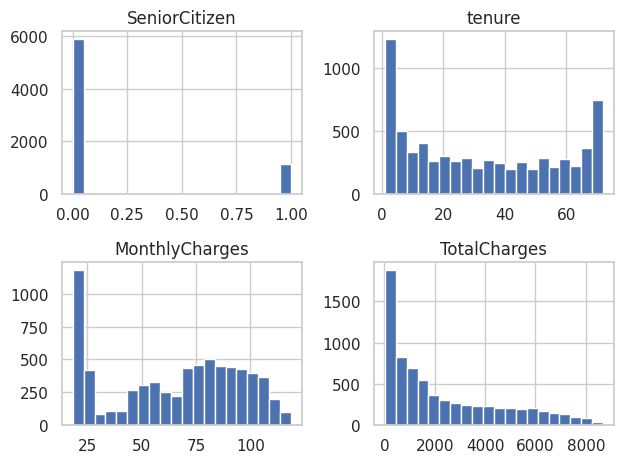

In [19]:
plt.figure(figsize=(7,7))

df[numerical_cols].hist(
    bins = 20
)

plt.tight_layout()

plt.show()

#### Observation

Features such as tenure and monthly charges exhibit varying distributions, suggesting different customer behaviors and usage patterns.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

### Categorical Feature Analysis

In [21]:
for col in df.select_dtypes(include= 'object').columns:
  print(col)
  print(df[col].unique())
  print('-'*50)

gender
['Female' 'Male']
--------------------------------------------------
Partner
['Yes' 'No']
--------------------------------------------------
Dependents
['No' 'Yes']
--------------------------------------------------
PhoneService
['No' 'Yes']
--------------------------------------------------
MultipleLines
['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity
['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup
['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection
['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport
['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV
['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingM

### Mapping `Churn` to 0 and 1

In [22]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

### Customer Churn Distribution

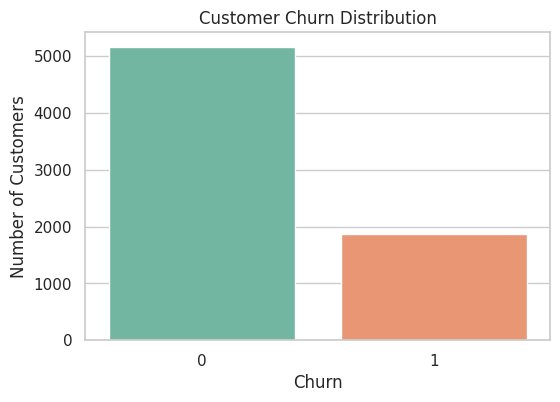

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data = df,
    x = 'Churn',
    palette= 'Set2')

plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.title('Customer Churn Distribution')

plt.show()


### Observation

The majority of customers have not churned. The dataset exhibits moderate class imbalance, with non-churners forming the larger group.

### Customer Churn by Contract Type

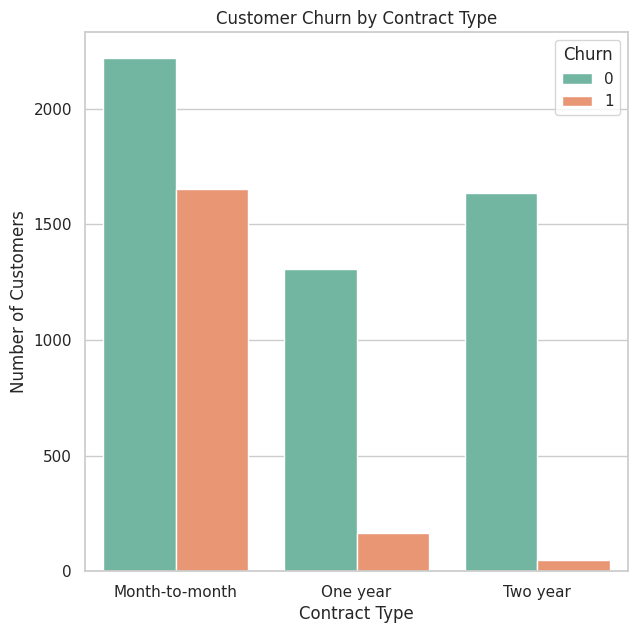

In [24]:
plt.figure(figsize=(7,7))

sns.countplot(
    data = df,
    x = 'Contract',
    hue = 'Churn',
    palette = 'Set2'
)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

###Observation
Month-to-month customers typically churn much more frequently than those with one-year or two-year contracts.

### Customer Churn by Internet Service

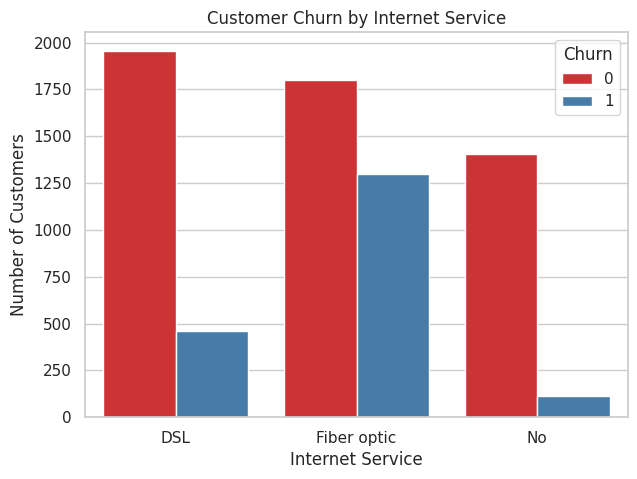

In [25]:
plt.figure(figsize = (7,5))

sns.countplot(
    data = df,
    x = 'InternetService',
    hue = 'Churn',
    palette= 'Set1'
)

plt.title('Customer Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

### Observation:
Customers with **Fiber optic** internet service show the highest churn, while customers with **DSL** and especially those with **no internet service** are more likely to stay. This suggests that internet service type is associated with customer churn.

### Customer Churn by Payment Method

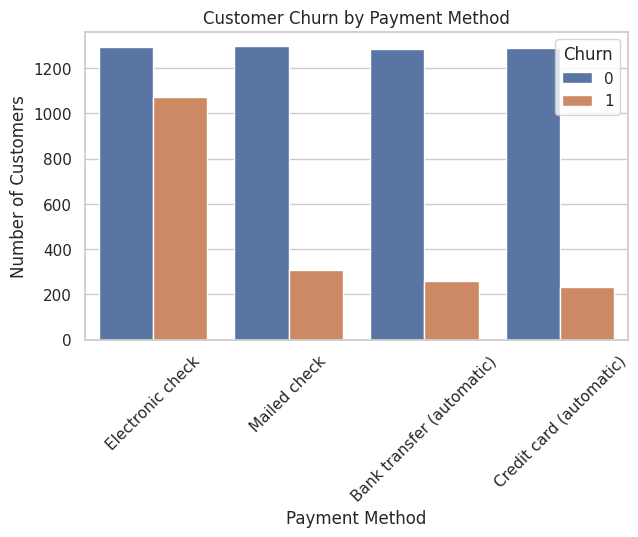

In [26]:
plt.figure(figsize=(7,4))

sns.countplot(
    data = df,
    x = 'PaymentMethod',
    hue = 'Churn')
plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()


### Customer Churn by Senior Citizen

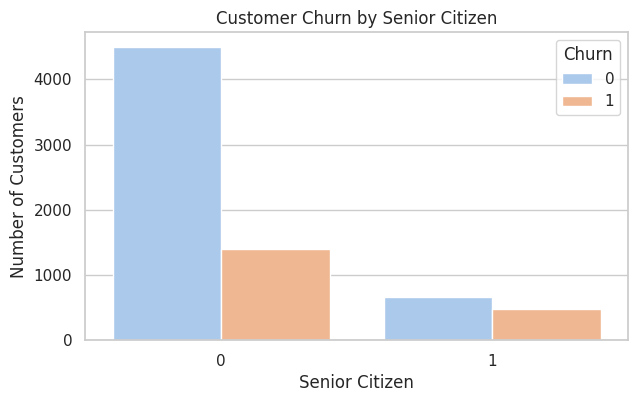

In [27]:
plt.figure(figsize=(7,4))

sns.countplot(
    data = df,
    x = 'SeniorCitizen',
    hue='Churn',
    palette='pastel'
)
plt.title('Customer Churn by Senior Citizen')
plt.xlabel('Senior Citizen')
plt.ylabel('Number of Customers')

plt.show()

### Observation:
Most customers are not senior citizens. However, senior citizens have a relatively higher proportion of churn compared to non-senior customers, suggesting that age group may influence customer retention.

### Distribution of Customer Tenure

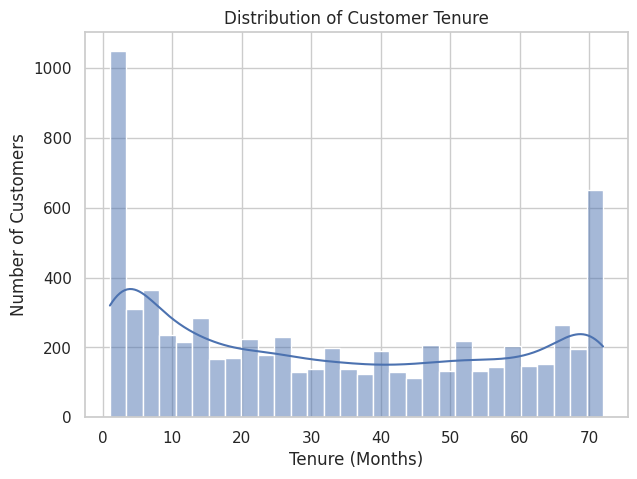

In [28]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x='tenure',
    bins=30,
    kde=True
)
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()

### Observation:
The tenure distribution is bimodal, with many customers being either very new or long-term customers. This indicates the presence of two distinct customer groups and suggests that tenure may have a strong influence on customer churn.

### Tenure by Churn

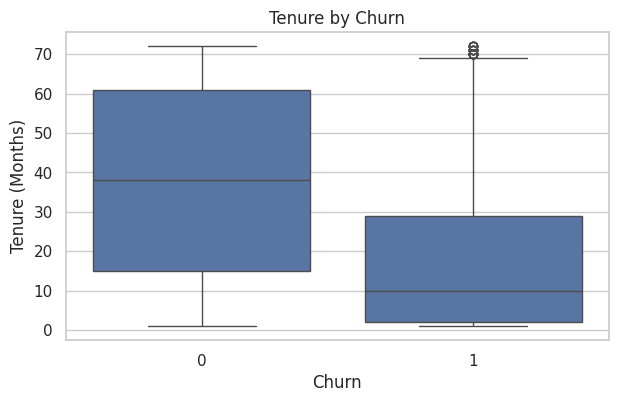

In [29]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()


### Observation:
Customers who churned generally have much lower tenure compared to those who stayed. This suggests that newer customers are more likely to leave, while long-term customers tend to remain with the company.

### Distribution of Monthly Charges

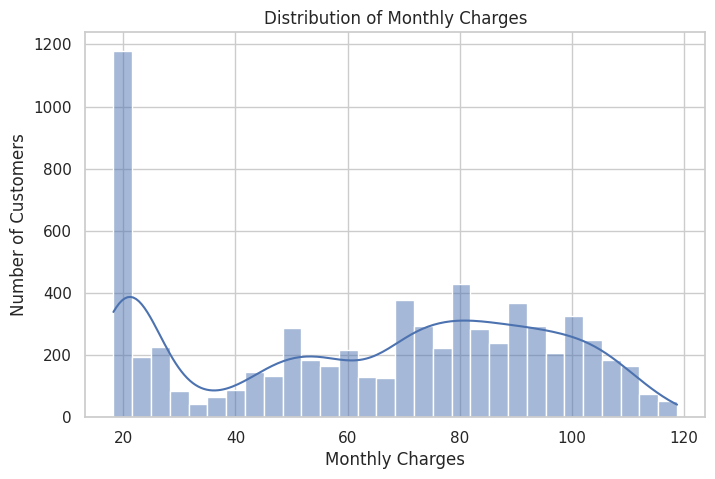

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    data = df,
    x = 'MonthlyCharges',
    bins = 30,
    kde = True
)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

### Observation:
The distribution of monthly charges is multimodal, indicating the presence of different customer segments. Most customers are concentrated in the lower and higher charge ranges, suggesting a variety of service plans and pricing levels.

### Relationship Between Numerical Features and Churn

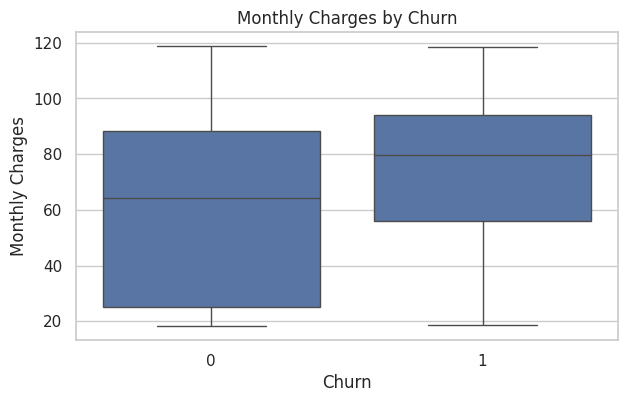

In [31]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()


### Observation:
Customers who churned generally have much lower tenure compared to those who stayed. This suggests that newer customers are more likely to leave, while long-term customers tend to remain with the company.

### Encoding Categorical Variables

In [32]:
df_encoded = pd.get_dummies(
    data=df,
    drop_first=True,
    dtype = 'int'
)

#### Observation

Categorical variables were transformed into numerical representations to make them suitable for machine learning algorithms.

### Correlation Analysis

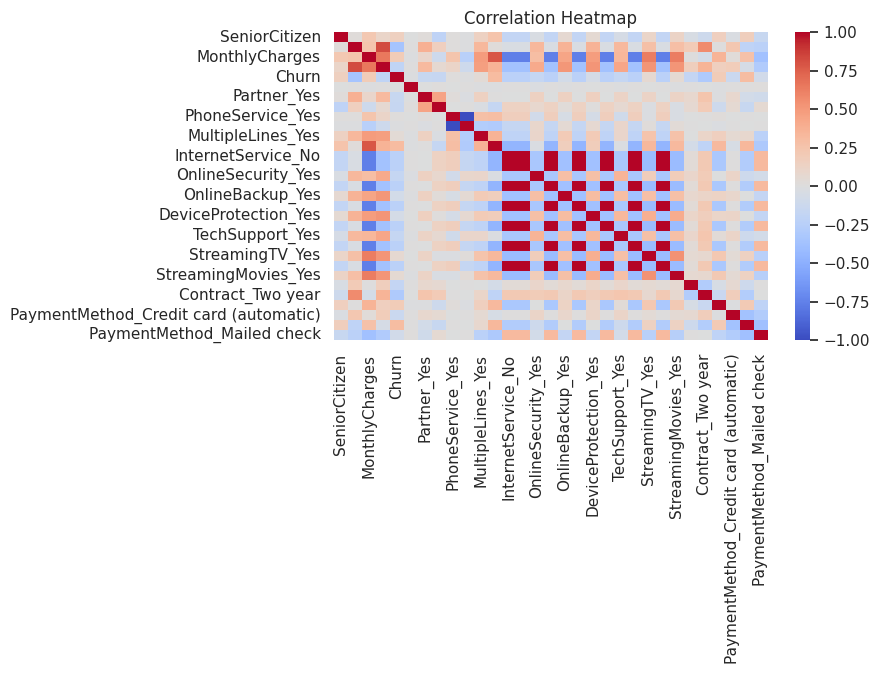

In [33]:
plt.figure(figsize=(7,4))

sns.heatmap(
    data=df_encoded.corr(),
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

#### Observation

Several variables exhibit moderate correlations. No severe multicollinearity is immediately evident, although some related service variables show associations.

### Pairwise Relationships

<Figure size 500x500 with 0 Axes>

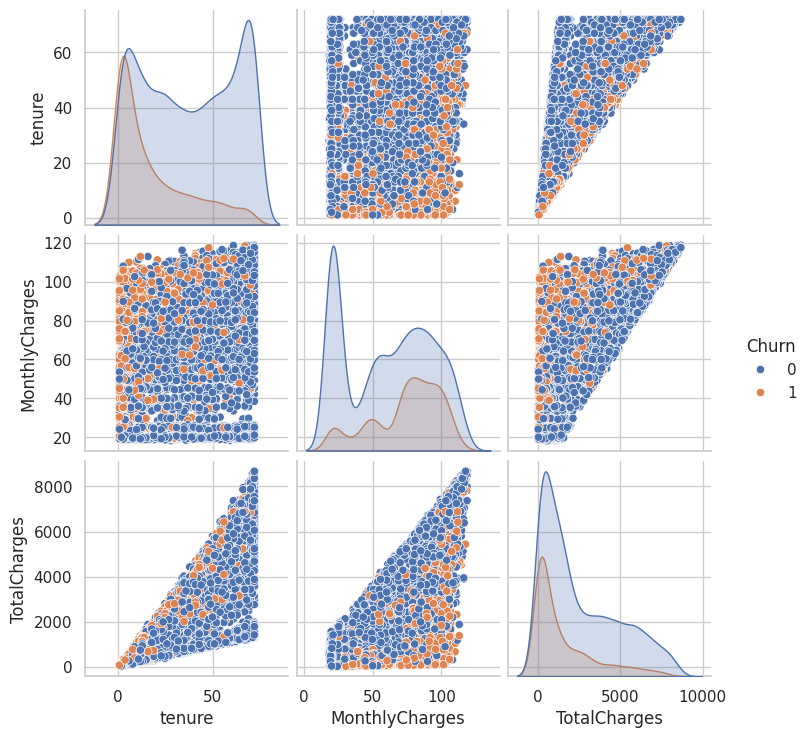

In [34]:
plt.figure(figsize=(5,5))
sns.pairplot(
    df[['tenure',
        'MonthlyCharges',
        'TotalCharges',
        'Churn']],
    hue='Churn'
)

plt.show()

#### Observation

Pairwise plots provide insight into the relationships among numerical variables and help reveal possible clustering patterns.

## 7. Feature Engineering

### Defining Features and Target Variable

In [35]:
X = df_encoded.drop('Churn',axis=1)
y = df_encoded['Churn']

In [36]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [37]:
print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


In [38]:
y.value_counts()

,count
Churn,
0,5163
1,1869


In [39]:
y.value_counts(normalize=True)*100

,proportion
Churn,
0,73.421502
1,26.578498


#### Observation

The predictor variables were separated from the target variable (`Churn`) to prepare the data for model training and evaluation.

In [40]:
df_encoded.to_csv(
    'cleaned_telco_churn.csv',
    index=False
)

## 8. Train-Test Split

### Splitting the Dataset

In [41]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [42]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


In [43]:
y.value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


In [44]:
y_train.value_counts(normalize=True)

,proportion
Churn,
0,0.734222
1,0.265778


In [45]:
y_test.value_counts(normalize=True)

,proportion
Churn,
0,0.734186
1,0.265814


#### Observation

The dataset was divided into training and testing sets to evaluate the model's ability to generalize to unseen data.

Stratified sampling was used to preserve the class distribution of the target variable.

## 9. Feature Scaling

### Standardization

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
scaler = StandardScaler()

In [48]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns = X_train.columns
)

In [50]:
X_train_scaled_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,...,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03,5.625000e+03
mean,-4.736952e-17,-1.291609e-16,3.157968e-17,8.842310e-18,-8.589672e-17,-8.084397e-17,-3.157968e-17,2.400055e-17,1.484245e-17,3.600083e-17,...,-5.621183e-17,1.831621e-17,-5.621183e-17,-4.800111e-17,2.526374e-17,-5.558023e-17,-5.368545e-17,-3.600083e-17,-5.842240e-18,3.157968e-17
std,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,...,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00
min,-4.393189e-01,-1.286145e+00,-1.547843e+00,-1.003365e+00,-1.003740e+00,-9.724678e-01,-6.539610e-01,-3.053048e+00,-3.275415e-01,-8.579692e-01,...,-5.229616e-01,-7.978732e-01,-5.229616e-01,-7.999636e-01,-5.157872e-01,-5.641422e-01,-1.213030e+00,-5.248907e-01,-7.161775e-01,-5.394682e-01
25%,-4.393189e-01,-9.601500e-01,-9.698847e-01,-8.301191e-01,-1.003740e+00,-9.724678e-01,-6.539610e-01,3.275415e-01,-3.275415e-01,-8.579692e-01,...,-5.229616e-01,-7.978732e-01,-5.229616e-01,-7.999636e-01,-5.157872e-01,-5.641422e-01,-1.213030e+00,-5.248907e-01,-7.161775e-01,-5.394682e-01
50%,-4.393189e-01,-1.451620e-01,1.860324e-01,-3.918414e-01,9.962736e-01,-9.724678e-01,-6.539610e-01,3.275415e-01,-3.275415e-01,-8.579692e-01,...,-5.229616e-01,-7.978732e-01,-5.229616e-01,-7.999636e-01,-5.157872e-01,-5.641422e-01,8.243821e-01,-5.248907e-01,-7.161775e-01,-5.394682e-01
75%,-4.393189e-01,9.550717e-01,8.320837e-01,6.591681e-01,9.962736e-01,1.028312e+00,1.529143e+00,3.275415e-01,-3.275415e-01,1.165543e+00,...,-5.229616e-01,1.253332e+00,-5.229616e-01,1.250057e+00,-5.157872e-01,-5.641422e-01,8.243821e-01,-5.248907e-01,1.396302e+00,-5.394682e-01
max,2.276251e+00,1.607062e+00,1.782062e+00,2.805224e+00,9.962736e-01,1.028312e+00,1.529143e+00,3.275415e-01,3.053048e+00,1.165543e+00,...,1.912186e+00,1.253332e+00,1.912186e+00,1.250057e+00,1.938784e+00,1.772603e+00,8.243821e-01,1.905159e+00,1.396302e+00,1.853677e+00


#### Observation

Feature scaling was applied to ensure that variables with different magnitudes contribute equally during model training. Scaling is particularly important for Logistic Regression.

## 10. Logistic Regression

### Model Training

In [51]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()


In [52]:
lr_model.fit(X_train_scaled,y_train)

LogisticRegression()

#### Observation

Logistic Regression was used as the baseline classification model due to its interpretability and strong statistical foundations.

## 11. Model Evaluation

In [53]:
y_pred = lr_model.predict(X_test_scaled)

In [54]:
print(y_pred)

[0 1 0 ... 0 0 0]


In [55]:
y_prob = lr_model.predict_proba(X_test_scaled)[:,1]

In [56]:
print(y_prob)

[0.01711495 0.59613179 0.00476432 ... 0.1307601  0.02479905 0.00438623]


In [57]:
from sklearn.metrics import accuracy_score

In [58]:
accuracy_score(y_test,y_pred)

0.8038379530916845

### Confusion Matrix

In [59]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[916 117]
 [159 215]]


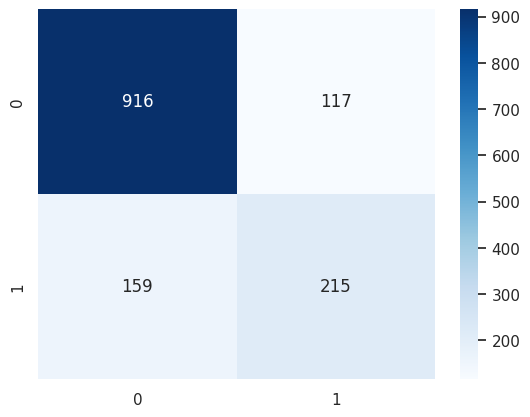

In [60]:
import os

os.makedirs('images', exist_ok=True)

plt.savefig(
    'images/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)


sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues'
)

plt.show()

#### Observation

The confusion matrix summarizes the model's predictions and provides insight into true positives, true negatives, false positives, and false negatives.

### Classification Report

In [61]:
from sklearn.metrics import classification_report

In [62]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



#### Observation

Precision, recall, and F1-score provide a more comprehensive assessment of classification performance than accuracy alone.

In [63]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.8356727976766699)

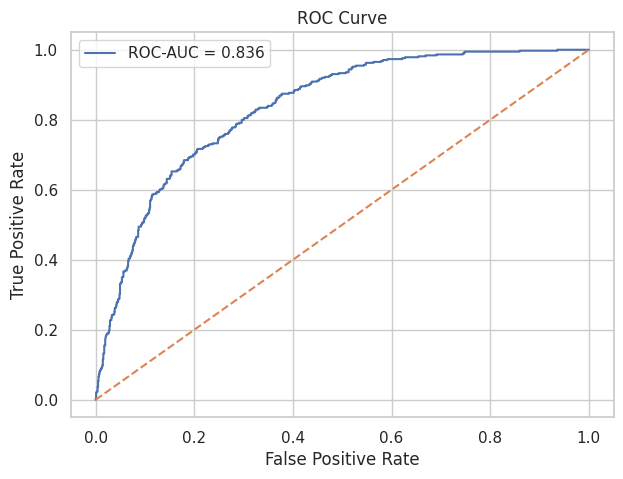

In [116]:
from sklearn.metrics import roc_curve

y_prob = y_prob

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_prob):.3f}')
plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.savefig(
    'images/roc_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.show()

#### Observation

The ROC curve evaluates the model across different classification thresholds. ROC-AUC measures the model's ability to distinguish churners from non-churners.

## 12. Decision Tree

Decision Trees partition the feature space recursively by selecting splits that maximize information gain or minimize impurity.

They are highly interpretable but prone to overfitting if left unconstrained.

In [65]:
from sklearn.tree import DecisionTreeClassifier

### Model Training

In [66]:
tree_model = DecisionTreeClassifier(random_state=42)

In [67]:
tree_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [68]:
tree_pred = tree_model.predict(X_test)

In [69]:
tree_pred_prob = tree_model.predict_proba(X_test)[:,1]

### Evaluation

In [70]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [71]:
accuracy_score(y_test,tree_pred)

0.7185501066098081

In [72]:
confusion_matrix(y_test,tree_pred)

array([[838, 195],
       [201, 173]])

In [73]:
classification_report(y_test,tree_pred)

'              precision    recall  f1-score   support\n\n           0       0.81      0.81      0.81      1033\n           1       0.47      0.46      0.47       374\n\n    accuracy                           0.72      1407\n   macro avg       0.64      0.64      0.64      1407\nweighted avg       0.72      0.72      0.72      1407\n'

In [74]:
roc_auc_score(y_test,tree_pred_prob)


np.float64(0.636638004669438)

#### Observation

The Decision Tree captures nonlinear relationships but may exhibit high variance. Although it performs reasonably well, its predictive performance is lower than Logistic Regression.

## 13. Random Forest

Random Forest is an ensemble method that combines multiple Decision Trees through bootstrap sampling and bagging.

Averaging predictions from many trees reduces variance and improves generalization.

In [75]:
from sklearn.ensemble import RandomForestClassifier

### Model Training

In [76]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [77]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [78]:
rf_pred = rf_model.predict(X_test)

In [79]:
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [80]:
accuracy_score(y_test,rf_pred)


0.7896233120113717

In [81]:
confusion_matrix(y_test,rf_pred)


array([[917, 116],
       [180, 194]])

In [82]:
classification_report(y_test,rf_pred)


'              precision    recall  f1-score   support\n\n           0       0.84      0.89      0.86      1033\n           1       0.63      0.52      0.57       374\n\n    accuracy                           0.79      1407\n   macro avg       0.73      0.70      0.71      1407\nweighted avg       0.78      0.79      0.78      1407\n'

In [83]:
roc_auc_score(y_test,rf_prob)

np.float64(0.8164903116927489)

#### Observation

Random Forest achieves competitive performance by reducing the variance associated with individual trees and capturing complex interactions among features.

## 14. Cross Validation

Cross-validation provides a more reliable estimate of model performance by repeatedly training and validating models on different subsets of the data.

In [84]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

### Logistic Regression

In [85]:
lr_model = LogisticRegression(random_state = 42)

In [86]:
cv_scores = cross_val_score(
    estimator = lr_model,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring= 'roc_auc'
)

In [87]:
print(cv_scores)

[0.83663665 0.87407986 0.8408375  0.81921174 0.85914712]


In [88]:
print(cv_scores.mean())

0.8459825730643711


In [89]:
print(cv_scores.std())

0.018938102011084243


#### Observation

Logistic Regression demonstrated stable performance across folds with a mean ROC-AUC of approximately 0.846.

### Random Forest

In [90]:
rf_model = RandomForestClassifier(random_state=42)

In [91]:
cv_score = cross_val_score(
    estimator = rf_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring= 'roc_auc'
)

In [92]:
print(cv_score)
print(cv_score.mean())
print(cv_score.std())

[0.82267162 0.83669941 0.8242892  0.80288411 0.82993149]
0.8232951646732044
0.011328748396626757


#### Observation

Random Forest produced consistent results across folds, although its average performance was slightly below Logistic Regression prior to tuning.

## 15. Hyperparameter Tuning

Hyperparameter tuning was performed using GridSearchCV to identify model configurations that maximize ROC-AUC while controlling overfitting.

### Decision Tree

In [93]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [94]:
dt_model = DecisionTreeClassifier(random_state=42)

In [95]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

In [96]:
grid_search_dt = GridSearchCV(
    estimator = dt_model,
    param_grid = param_grid,
    cv = 5,
    scoring = 'roc_auc',
    n_jobs = -1
)

In [ ]:
grid_search_dt.fit(X_train,y_train)

In [ ]:
print(grid_search_dt.best_params_)

In [ ]:
print(grid_search_dt.best_score_)

In [100]:
best_tree = grid_search_dt.best_estimator_

In [101]:
tree_prob = best_tree.predict_proba(X_test)[:,1]

In [102]:
roc_auc_score(y_test,tree_prob)

np.float64(0.8191524607730973)

#### Observation

The optimal Decision Tree preferred moderate depth, suggesting that controlling complexity improves generalization.

### Random Forest

In [103]:
rf_model = RandomForestClassifier(random_state=42)

In [104]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 5]
}

In [105]:
grid_search_rf = GridSearchCV(
    estimator = rf_model,
    param_grid = param_grid_rf,
    cv = 5,
    scoring = 'roc_auc',
    n_jobs = -1
)

In [106]:
grid_search_rf.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_leaf': [1, 2, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

In [ ]:
print(grid_search_rf.best_params_)
print(grid_search_rf.best_score_)

In [ ]:
best_forest = grid_search_rf.best_estimator_

In [ ]:
rf_prob = best_forest.predict_proba(X_test)[:,1]

In [ ]:
roc_auc_score(y_test,rf_prob)

#### Observation

Hyperparameter tuning significantly improved Random Forest performance, bringing it close to Logistic Regression.

## 16. Model Comparison

| Model               | CV ROC-AUC |
| ------------------- | ---------: |
| Logistic Regression |      0.846 |
| Tuned Random Forest |      0.845 |
| Tuned Decision Tree |      0.827 |


### Observation

Logistic Regression achieved the highest cross-validated ROC-AUC and was selected as the final model.

Despite its simplicity, Logistic Regression outperformed more complex tree-based models, illustrating that increased model complexity does not necessarily translate into better predictive performance.

## 17. Model Interpretation

Since Logistic Regression achieved the highest cross-validated ROC-AUC, it was selected as the final model. To interpret the factors influencing customer churn, the model was refitted on the training data and its coefficients were examined.

In [ ]:
from sklearn.linear_model import LogisticRegression

best_lr = LogisticRegression(random_state=42)

best_lr.fit(X_train_scaled, y_train)

### Logistic Regression Coefficients

Logistic Regression provides interpretable coefficients that describe the effect of individual variables on the odds of churn.

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lr.coef_[0]
})

coef_df = coef_df.sort_values(by='Coefficient')
coef_df

In [113]:
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient'])

coef_df.sort_values(by='Odds Ratio')

,Feature,Coefficient,Odds Ratio
1,tenure,-1.347613,0.259860
2,MonthlyCharges,-0.851551,0.426753
25,Contract_Two year,-0.602591,0.547392
24,Contract_One year,-0.310898,0.732789
13,OnlineSecurity_Yes,-0.136804,0.872141
19,TechSupport_Yes,-0.118240,0.888483
6,Dependents_Yes,-0.105956,0.899464
14,OnlineBackup_No internet service,-0.088138,0.915634
16,DeviceProtection_No internet service,-0.088138,0.915634
18,TechSupport_No internet service,-0.088138,0.915634


In [114]:
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])

coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

,Feature,Coefficient,Odds Ratio,Abs_Coefficient
1,tenure,-1.347613,0.259860,1.347613
2,MonthlyCharges,-0.851551,0.426753,0.851551
10,InternetService_Fiber optic,0.727745,2.070407,0.727745
3,TotalCharges,0.639028,1.894639,0.639028
25,Contract_Two year,-0.602591,0.547392,0.602591
24,Contract_One year,-0.310898,0.732789,0.310898
21,StreamingTV_Yes,0.249702,1.283642,0.249702
23,StreamingMovies_Yes,0.236368,1.266641,0.236368
9,MultipleLines_Yes,0.214359,1.239068,0.214359
28,PaymentMethod_Electronic check,0.181473,1.198982,0.181473


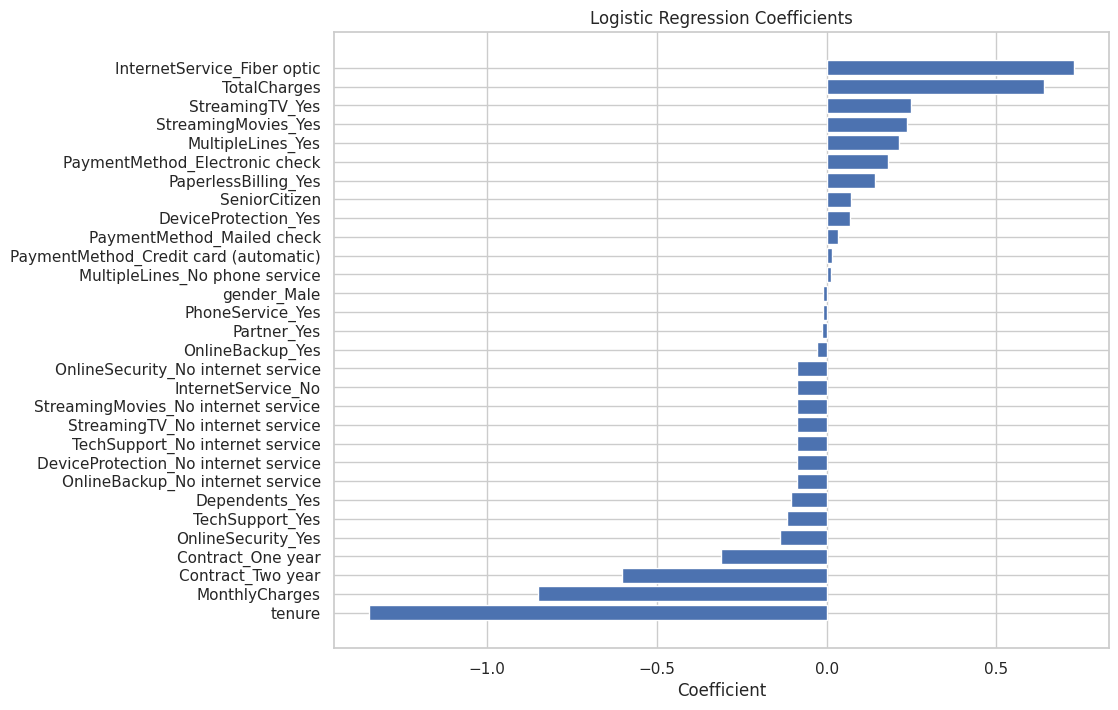

In [117]:
coef_plot_df = coef_df.sort_values(by='Coefficient')

plt.figure(figsize=(10,8))

plt.barh(
    coef_plot_df['Feature'],
    coef_plot_df['Coefficient']
)

plt.xlabel('Coefficient')
plt.title('Logistic Regression Coefficients')

plt.savefig(
    'images/logistic_coefficients.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Observation

Tenure emerged as the strongest predictor of customer churn. Customers with longer tenure exhibited substantially lower odds of leaving the company.

Customers using fiber optic internet services showed higher churn risk compared with customers using other internet services.

Long-term contracts, particularly two-year contracts, were associated with significantly lower churn probabilities, highlighting the importance of customer commitment.

Streaming services, multiple lines, electronic check payments, and paperless billing were associated with moderately higher churn risk.

Conversely, customers subscribing to online security and technical support services demonstrated lower churn tendencies, suggesting that value-added services may contribute to customer retention.

## 18. Business Recommendations

### Strengthen Customer Retention During Early Tenure

Tenure emerged as the most influential predictor of churn.

Retention programs should focus particularly on customers during their initial months, where the risk of attrition is highest.

### Encourage Long-Term Contracts

Customers with one-year and two-year contracts exhibited significantly lower churn probabilities.

Providing discounts and loyalty incentives may encourage customers to transition from month-to-month plans to long-term contracts.

### Improve Fiber Optic Customer Experience

Customers using fiber optic internet services displayed higher churn tendencies.

Further investigation into pricing, service quality, and customer satisfaction among fiber optic users may help reduce attrition.

### Promote Value-Added Services

Customers subscribing to online security and technical support services exhibited lower churn risk.

Increasing adoption of these services may improve customer satisfaction and strengthen retention.

### Review Payment and Billing Practices

Electronic check payments and paperless billing were associated with higher churn probabilities.

Understanding customer preferences and simplifying billing processes may improve customer experience.

## 19. Conclusion

This project developed and evaluated multiple machine learning models for predicting customer churn using the Telco Customer Churn dataset.

Logistic Regression, Decision Tree, and Random Forest models were trained and compared using cross-validation and ROC-AUC.

Among the models considered, Logistic Regression achieved the highest cross-validated ROC-AUC and was selected as the final model.

The analysis identified tenure, contract type, internet service, and monthly charges as major factors influencing customer churn.

The results demonstrate how machine learning can be leveraged not only for prediction but also for generating actionable business insights that support customer retention strategies.

In [115]:
import os
os.makedirs('models', exist_ok=True)

import joblib

joblib.dump(best_lr, 'models/logistic_regression.pkl')
joblib.dump(best_forest, 'models/random_forest.pkl')

['models/random_forest.pkl']